In [1]:
pip install torchcodec

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------------------------- -- 2.1/2.2 MB 25.3 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 20.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import librosa
import numpy as np

# ścieżka do pliku audio
audio_path = r"VOiCES_devkit/source-16k/sp2035/Lab41-SRI-VOiCES-src-sp2035-ch147960-sg0010.wav"

# wczytanie audio
# sr=None -> zachowuje oryginalne próbkowanie pliku
y, sr = librosa.load(audio_path, sr=None)

print("Sampling rate:", sr)
print("Liczba próbek:", len(y))
print("Długość [s]:", len(y) / sr)
print("Kształt:", y.shape)
print("Typ:", y.dtype)

C:\Users\idani\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sampling rate: 16000
Liczba próbek: 153360
Długość [s]: 9.585
Kształt: (153360,)
Typ: float32


In [3]:
from pathlib import Path
import pandas as pd

SOURCE_DIR = Path(r"VOiCES_devkit\source-16k")

rows = []
for speaker_dir in sorted([p for p in SOURCE_DIR.iterdir() if p.is_dir()]):
    wavs = sorted(speaker_dir.rglob("*.wav"))
    rows.append({
        "speaker": speaker_dir.name,
        "n_files": len(wavs)
    })

df = pd.DataFrame(rows).sort_values(["n_files", "speaker"], ascending=[False, True])
print(df)
print("\nLiczba speakerów:", len(df))
print("Łączna liczba plików:", df["n_files"].sum())

    speaker  n_files
0    sp0032        2
1    sp0083        2
2    sp0093        2
3    sp0112        2
4    sp0115        2
..      ...      ...
295  sp8605        2
296  sp8635        2
297  sp8677        2
298  sp8713        2
299  sp8855        2

[300 rows x 2 columns]

Liczba speakerów: 300
Łączna liczba plików: 600


In [4]:
from pathlib import Path
import pandas as pd
import random

SOURCE_DIR = Path(r"VOiCES_devkit\source-16k")
SEED = 123
random.seed(SEED)

# 1. speakerzy
speaker_dirs = sorted([p for p in SOURCE_DIR.iterdir() if p.is_dir()])
speakers = [p.name for p in speaker_dirs]

print("Liczba speakerów:", len(speakers))
print("Przykładowi speakerzy:", speakers[:10])

# 2. wybór 5 speakerów do klasy allow
allow_speakers = speakers[:5]   # na razie prosto; potem można zmienić
print("ALLOW:", allow_speakers)

# 3. budowa metadanych na poziomie całych nagrań
rows = []

for speaker_dir in speaker_dirs:
    speaker = speaker_dir.name
    label = 1 if speaker in allow_speakers else 0

    wavs = sorted(speaker_dir.rglob("*.wav"))
    wavs = [str(p) for p in wavs]
    random.shuffle(wavs)

    n = len(wavs)
    n_train = int(0.7 * n)
    n_valid = int(0.1 * n)
    n_test = n - n_train - n_valid

    for i, wav in enumerate(wavs):
        if i < n_train:
            split = "train"
        elif i < n_train + n_valid:
            split = "valid"
        else:
            split = "test"

        rows.append({
            "speaker": speaker,
            "label": label,
            "split": split,
            "audio_path": wav
        })

meta = pd.DataFrame(rows)
print(meta.head())
print(meta.groupby(["split", "label"]).size())

meta.to_csv("metadata_recording_level.csv", index=False)

Liczba speakerów: 300
Przykładowi speakerzy: ['sp0032', 'sp0083', 'sp0093', 'sp0112', 'sp0115', 'sp0118', 'sp0122', 'sp0150', 'sp0154', 'sp0159']
ALLOW: ['sp0032', 'sp0083', 'sp0093', 'sp0112', 'sp0115']
  speaker  label  split                                         audio_path
0  sp0032      1  train  VOiCES_devkit\source-16k\sp0032\Lab41-SRI-VOiC...
1  sp0032      1   test  VOiCES_devkit\source-16k\sp0032\Lab41-SRI-VOiC...
2  sp0083      1  train  VOiCES_devkit\source-16k\sp0083\Lab41-SRI-VOiC...
3  sp0083      1   test  VOiCES_devkit\source-16k\sp0083\Lab41-SRI-VOiC...
4  sp0093      1  train  VOiCES_devkit\source-16k\sp0093\Lab41-SRI-VOiC...
split  label
test   0        295
       1          5
train  0        295
       1          5
dtype: int64


In [5]:
from pathlib import Path
import pandas as pd
import random

SOURCE_DIR = Path(r"VOiCES_devkit\source-16k")
SEED = 123
random.seed(SEED)

# --------------------------------------------------
# 1. Wczytanie listy speakerów i ich nagrań
# --------------------------------------------------
speaker_to_wavs = {}

for speaker_dir in sorted([p for p in SOURCE_DIR.iterdir() if p.is_dir()]):
    wavs = sorted(speaker_dir.rglob("*.wav"))
    if len(wavs) > 0:
        speaker_to_wavs[speaker_dir.name] = [str(p) for p in wavs]

print("Liczba speakerów:", len(speaker_to_wavs))

# --------------------------------------------------
# 2. Wybór 5 speakerów do klasy allow
#    Na razie: pierwszych 5 alfabetycznie
#    Możesz tu wpisać własną listę ręcznie
# --------------------------------------------------
all_speakers = sorted(speaker_to_wavs.keys())
allow_speakers = all_speakers[:5]

# np. ręcznie:
# allow_speakers = ["sp0001", "sp0007", "sp0012", "sp0020", "sp0033"]

print("ALLOW:", allow_speakers)

# --------------------------------------------------
# 3. Funkcja do globalnego splitu listy plików
# --------------------------------------------------
def split_list(items, train_ratio=0.7, valid_ratio=0.1, test_ratio=0.2):
    items = items.copy()
    random.shuffle(items)

    n = len(items)
    n_train = int(round(train_ratio * n))
    n_valid = int(round(valid_ratio * n))

    # korekta, żeby wszystko się zgadzało
    if n_train + n_valid > n:
        n_valid = max(0, n - n_train)

    n_test = n - n_train - n_valid

    train_items = items[:n_train]
    valid_items = items[n_train:n_train + n_valid]
    test_items = items[n_train + n_valid:]

    return train_items, valid_items, test_items

# --------------------------------------------------
# 4. Sprytny split
# --------------------------------------------------
rows = []

# ---- klasa 1: allow
allow_holdout = []

for speaker in allow_speakers:
    wavs = speaker_to_wavs[speaker].copy()
    random.shuffle(wavs)

    if len(wavs) == 1:
        # awaryjnie: jedyne nagranie do train
        train_wav = wavs[0]
        rows.append({
            "speaker": speaker,
            "label": 1,
            "split": "train",
            "audio_path": train_wav
        })
    else:
        # jedno nagranie do train
        train_wav = wavs[0]
        rows.append({
            "speaker": speaker,
            "label": 1,
            "split": "train",
            "audio_path": train_wav
        })

        # reszta do holdout
        for wav in wavs[1:]:
            allow_holdout.append({
                "speaker": speaker,
                "label": 1,
                "audio_path": wav
            })

# holdout klasy 1 dzielimy na valid/test
random.shuffle(allow_holdout)

n_holdout = len(allow_holdout)
n_valid_pos = max(1, n_holdout // 2) if n_holdout >= 2 else 0
n_test_pos = n_holdout - n_valid_pos

for item in allow_holdout[:n_valid_pos]:
    rows.append({
        "speaker": item["speaker"],
        "label": 1,
        "split": "valid",
        "audio_path": item["audio_path"]
    })

for item in allow_holdout[n_valid_pos:]:
    rows.append({
        "speaker": item["speaker"],
        "label": 1,
        "split": "test",
        "audio_path": item["audio_path"]
    })

# ---- klasa 0: not_allow
not_allow_speakers = [s for s in all_speakers if s not in allow_speakers]
not_allow_wavs = []

for speaker in not_allow_speakers:
    for wav in speaker_to_wavs[speaker]:
        not_allow_wavs.append({
            "speaker": speaker,
            "label": 0,
            "audio_path": wav
        })

random.shuffle(not_allow_wavs)

n0 = len(not_allow_wavs)
n0_train = int(round(0.7 * n0))
n0_valid = int(round(0.1 * n0))
if n0_train + n0_valid > n0:
    n0_valid = max(0, n0 - n0_train)
n0_test = n0 - n0_train - n0_valid

for item in not_allow_wavs[:n0_train]:
    rows.append({
        "speaker": item["speaker"],
        "label": 0,
        "split": "train",
        "audio_path": item["audio_path"]
    })

for item in not_allow_wavs[n0_train:n0_train + n0_valid]:
    rows.append({
        "speaker": item["speaker"],
        "label": 0,
        "split": "valid",
        "audio_path": item["audio_path"]
    })

for item in not_allow_wavs[n0_train + n0_valid:]:
    rows.append({
        "speaker": item["speaker"],
        "label": 0,
        "split": "test",
        "audio_path": item["audio_path"]
    })

# --------------------------------------------------
# 5. DataFrame + kontrola
# --------------------------------------------------
meta = pd.DataFrame(rows)

print("\nLiczba nagrań w splitach:")
print(meta.groupby(["split", "label"]).size())

print("\nLiczba speakerów allow w każdym splicie:")
print(meta[meta["label"] == 1].groupby("split")["speaker"].nunique())

print("\nPrzykład:")
print(meta.head())

meta.to_csv("metadata_recording_level.csv", index=False)
print("\nZapisano: metadata_recording_level.csv")

Liczba speakerów: 300
ALLOW: ['sp0032', 'sp0083', 'sp0093', 'sp0112', 'sp0115']

Liczba nagrań w splitach:
split  label
test   0        118
       1          3
train  0        413
       1          5
valid  0         59
       1          2
dtype: int64

Liczba speakerów allow w każdym splicie:
split
test     3
train    5
valid    2
Name: speaker, dtype: int64

Przykład:
  speaker  label  split                                         audio_path
0  sp0032      1  train  VOiCES_devkit\source-16k\sp0032\Lab41-SRI-VOiC...
1  sp0083      1  train  VOiCES_devkit\source-16k\sp0083\Lab41-SRI-VOiC...
2  sp0093      1  train  VOiCES_devkit\source-16k\sp0093\Lab41-SRI-VOiC...
3  sp0112      1  train  VOiCES_devkit\source-16k\sp0112\Lab41-SRI-VOiC...
4  sp0115      1  train  VOiCES_devkit\source-16k\sp0115\Lab41-SRI-VOiC...

Zapisano: metadata_recording_level.csv


In [7]:
from pathlib import Path
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

SEGMENTS_METADATA_PATH = Path("metadata_segment_level.csv")
SPECTROGRAM_DIR = Path("spectrograms_mel")
OUTPUT_METADATA_PATH = Path("metadata_spectrogram_level.csv")

N_MELS = 128
N_FFT = 1024
HOP_LENGTH = 256
FMIN = 20
FMAX = 8000

meta = pd.read_csv(SEGMENTS_METADATA_PATH)
rows = []

for _, row in meta.iterrows():
    segment_path = Path(row["segment_path"])
    split = row["split"]
    speaker = row["speaker"]
    label = int(row["label"])

    y, sr = librosa.load(segment_path, sr=None, mono=True)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    S_db = librosa.power_to_db(S, ref=np.max)

    out_dir = SPECTROGRAM_DIR / split / f"label_{label}" / speaker
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{segment_path.stem}.png"

    plt.figure(figsize=(3, 3))
    librosa.display.specshow(
        S_db,
        sr=sr,
        hop_length=HOP_LENGTH,
        x_axis=None,
        y_axis=None
    )
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(out_path, bbox_inches="tight", pad_inches=0)
    plt.close()

    rows.append({
        "speaker": speaker,
        "label": label,
        "split": split,
        "source_audio_path": row["source_audio_path"],
        "segment_path": str(segment_path),
        "spectrogram_path": str(out_path)
    })

spec_meta = pd.DataFrame(rows)
spec_meta.to_csv(OUTPUT_METADATA_PATH, index=False)

print("Saved:", OUTPUT_METADATA_PATH)
print(spec_meta.groupby(["split", "label"]).size())

Saved: metadata_spectrogram_level.csv
split  label
test   0         570
       1          15
train  0        2012
       1          25
valid  0         283
       1          10
dtype: int64


In [3]:
# 1) segmenty -> mel-spektrogramy PNG
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt

META_PATH = Path("metadata_segment_level.csv")
OUT_DIR = Path("spectrograms_png")

N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 128
FMIN = 20
FMAX = 8000

meta = pd.read_csv(META_PATH)

for _, row in meta.iterrows():
    segment_path = Path(row["segment_path"])
    split = row["split"]
    class_name = "allow" if int(row["label"]) == 1 else "not_allow"
    speaker = row["speaker"]

    y, sr = librosa.load(segment_path, sr=None, mono=True)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )
    S_db = librosa.power_to_db(S, ref=np.max)

    out_dir = OUT_DIR / split / class_name / speaker
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{segment_path.stem}.png"

    plt.figure(figsize=(3, 3))
    plt.imshow(S_db, origin="lower", aspect="auto", cmap="gray")
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(out_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Done")

Done


In [4]:
# 2) mean/std z train
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_tf_stats = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_ds_stats = datasets.ImageFolder("spectrograms_png/train", transform=train_tf_stats)
train_loader_stats = DataLoader(train_ds_stats, batch_size=64, shuffle=False)

mean_sum = 0.0
std_sum = 0.0
n_batches = 0

for x, _ in train_loader_stats:
    mean_sum += x.mean().item()
    std_sum += x.std().item()
    n_batches += 1

train_mean = mean_sum / n_batches
train_std = std_sum / n_batches

print("train_mean =", train_mean)
print("train_std  =", train_std)
print(train_ds_stats.class_to_idx)

train_mean = 0.3400350995361805
train_std  = 0.20935818646103144
{'allow': 0, 'not_allow': 1}


In [5]:
# 3) dataloadery
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])
])

train_ds = datasets.ImageFolder("spectrograms_png/train", transform=train_tf)
valid_ds = datasets.ImageFolder("spectrograms_png/valid", transform=eval_tf)
test_ds  = datasets.ImageFolder("spectrograms_png/test", transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(train_ds.class_to_idx)

{'allow': 0, 'not_allow': 1}


In [6]:
# 4) CNN z timm, trenowany od zera
import timm
import torch
from torch import nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model(
    "resnet18",
    pretrained=False,
    num_classes=2,
    in_chans=1
).to(DEVICE)

train_targets = torch.tensor([y for _, y in train_ds.samples])
class_counts = torch.bincount(train_targets, minlength=2).float()
class_weights = class_counts.sum() / (2.0 * class_counts)
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [8]:
# 5) trening + FAR/FRR
def evaluate(model, loader):
    model.eval()

    total = 0
    correct = 0

    false_accept = 0
    false_reject = 0
    n_not_allow = 0
    n_allow = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)
            pred = logits.argmax(dim=1)

            total += y.size(0)
            correct += (pred == y).sum().item()

            n_not_allow += (y == 0).sum().item()
            n_allow += (y == 1).sum().item()

            false_accept += ((y == 0) & (pred == 1)).sum().item()
            false_reject += ((y == 1) & (pred == 0)).sum().item()

    acc = correct / total if total > 0 else 0.0
    far = false_accept / n_not_allow if n_not_allow > 0 else 0.0
    frr = false_reject / n_allow if n_allow > 0 else 0.0

    return acc, far, frr


EPOCHS = 10
best_score = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum = 0.0
    n = 0

    for x, y in train_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * x.size(0)
        n += x.size(0)

    train_loss = loss_sum / n
    train_acc, train_far, train_frr = evaluate(model, train_loader)
    valid_acc, valid_far, valid_frr = evaluate(model, valid_loader)

    score = valid_far + valid_frr
    if best_score is None or score < best_score:
        best_score = score
        torch.save(model.state_dict(), "best_resnet18_from_scratch.pt")

    print(
        f"epoch={epoch:02d} "
        f"loss={train_loss:.4f} "
        f"train_acc={train_acc:.4f} "
        f"train_far={train_far:.4f} "
        f"train_frr={train_frr:.4f} "
        f"valid_acc={valid_acc:.4f} "
        f"valid_far={valid_far:.4f} "
        f"valid_frr={valid_frr:.4f}"
    )

epoch=01 loss=0.6312 train_acc=0.9877 train_far=1.0000 train_frr=0.0000 valid_acc=0.9659 valid_far=1.0000 valid_frr=0.0000
epoch=02 loss=0.4794 train_acc=0.6318 train_far=0.0800 train_frr=0.3718 valid_acc=0.6689 valid_far=0.3000 valid_frr=0.3322
epoch=03 loss=0.3312 train_acc=0.8297 train_far=0.3200 train_frr=0.1685 valid_acc=0.7884 valid_far=0.6000 valid_frr=0.1979
epoch=04 loss=0.3137 train_acc=0.9229 train_far=0.1200 train_frr=0.0765 valid_acc=0.8874 valid_far=0.5000 valid_frr=0.0989
epoch=05 loss=0.1161 train_acc=0.9961 train_far=0.0400 train_frr=0.0035 valid_acc=0.9590 valid_far=0.8000 valid_frr=0.0141
epoch=06 loss=0.0672 train_acc=0.9946 train_far=0.0800 train_frr=0.0045 valid_acc=0.9590 valid_far=1.0000 valid_frr=0.0071
epoch=07 loss=0.0646 train_acc=0.9813 train_far=0.1200 train_frr=0.0174 valid_acc=0.9454 valid_far=0.9000 valid_frr=0.0247
epoch=08 loss=0.1024 train_acc=0.9450 train_far=0.0400 train_frr=0.0552 valid_acc=0.9454 valid_far=0.5000 valid_frr=0.0389
epoch=09 loss=0.

In [9]:
# 6) test
model.load_state_dict(torch.load("best_resnet18_from_scratch.pt", map_location=DEVICE))
test_acc, test_far, test_frr = evaluate(model, test_loader)

print("TEST ACC =", test_acc)
print("TEST FAR =", test_far)
print("TEST FRR =", test_frr)

TEST ACC = 0.9333333333333333
TEST FAR = 0.8
TEST FRR = 0.04736842105263158


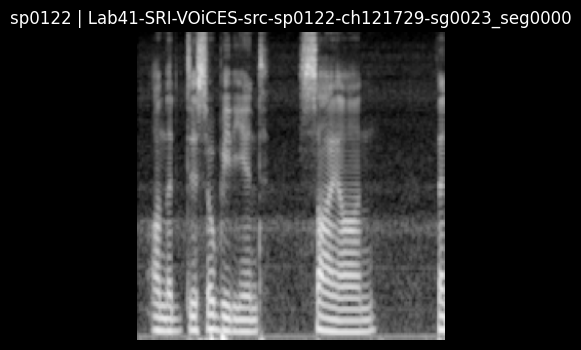

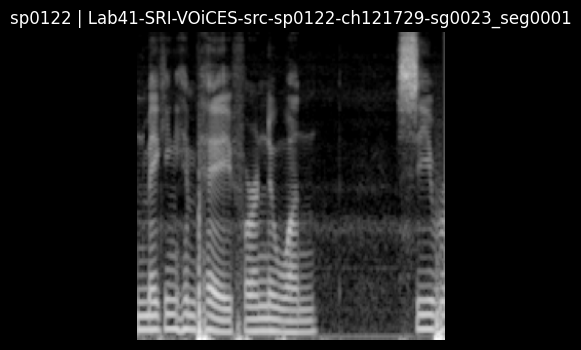

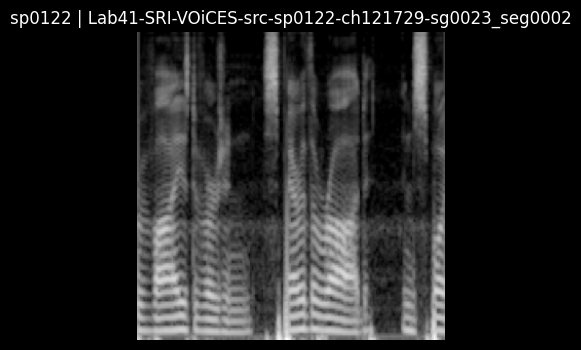

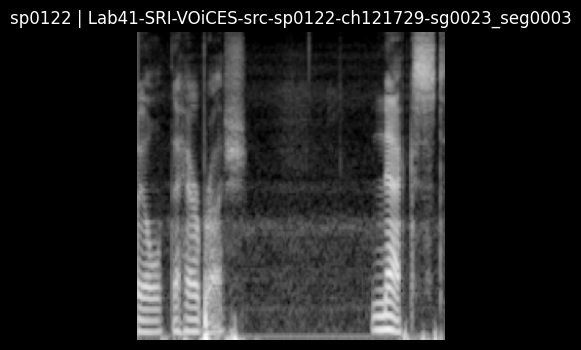

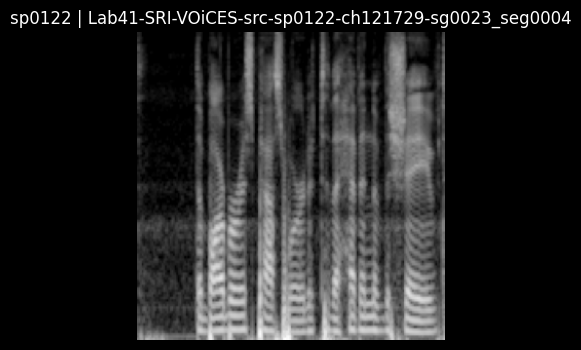

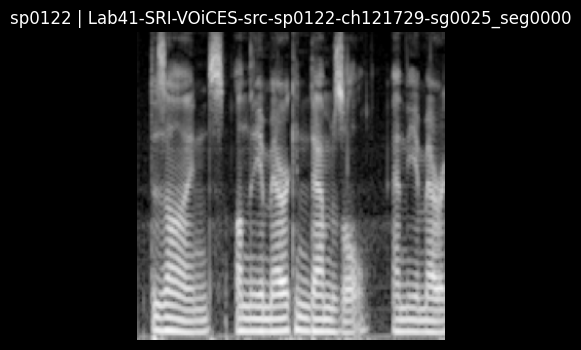

In [10]:
# 7) podglad kilku spektrogramow
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

paths = list(Path("spectrograms_png/train").rglob("*.png"))[:6]

for p in paths:
    img = Image.open(p)
    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(str(p.parent.name) + " | " + p.stem)
    plt.axis("off")
    plt.show()